# Q-Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning for model-free control
- Use exploration (e.g. ε-greedy) and tune hyperparameters

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — value iteration needed the transition probabilities handed to it; Q-learning drops that requirement and recovers the same optimal action values from sampled transitions alone.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **Q-learning**, one of the most important tabular RL algorithms.

Students will see how an agent updates action values from experience and gradually improves its behavior without knowing the environment in advance.

Why this matters: Q-learning is often the first real learning algorithm students can implement end to end.

It becomes the conceptual base for deep Q-networks later in the course.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Q-Learning Tutorial 1: Train Gymnasium FrozenLake-v1 with Python Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=ZhoIgo3qqLU)

Why this pick:
- step-by-step code walkthrough.
- Stays close to tabular Q-learning instead of jumping too quickly to deep RL.
- Good match for students implementing the algorithm from experience.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Q-value: how good it is to take an action in a state.
- Learning rate `alpha`: how strongly each new experience changes the estimate.
- Discount factor `gamma`: how much future reward still matters.
- TD target: reward now plus an estimate of future value.
- Off-policy: learning toward the greedy best-next-action target even if behavior is still exploring.

### Quick Check
- What appears in the Q-learning update?
- Why does Q-learning use the best next action?
- Why is Q-learning called model-free?
- Why is Q-learning called off-policy?

### Common Mistakes
- Reading the Q-table as final truth.
- Mixing learning rate with exploration rate.
- Forgetting Q-learning is off-policy.
- Thinking the agent must know the full environment model before learning starts.


## What this notebook should teach

By the end of this notebook, you should be able to:

- explain the Q-learning update rule
- identify the role of `alpha`, `gamma`, and `epsilon`
- understand why Q-learning is off-policy
- read a small tabular training loop without guessing what it is doing

## Why Q-Learning Matters

Q-learning is usually the first place students feel that an RL agent is truly **learning from experience**.

### Why is it model-free?

Because the agent does **not** need the full transition table or reward table in advance.
It can interact with the environment, collect experience, and update its table from samples.

That is a major shift from dynamic programming methods.

### Why is it off-policy?

Q-learning updates toward the value of the **best next action** according to the current table:

- the agent may behave with exploration, such as epsilon-greedy
- but the update still aims at the greedy target

So the behavior policy and the learning target are not exactly the same.
That is why the method is called **off-policy**.

### Plain-language intuition

Each experience teaches the agent:

`This action led to this reward, and from the next state I may still be able to do something even better.`

That is why the update includes both:

- reward now
- best estimated future value

### What students should watch for in the code

When the notebook updates `Q[state, action]`, ask:

- What new evidence did the agent just observe?
- What future estimate is being used?
- Why does the code use `max` for the next state?



## Q-Learning Reminder

The update rule is:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\right]
\]

### Read it in words

- start from the current estimate
- look at the reward you just received
- add discounted value of the best next action
- move your estimate a little in that direction


## 🌍 Worked Example on a Standard Benchmark — Taxi Dispatch with Q-Learning

> **What is real here and what is not.** The environment below is **Taxi**, one of the
> reference environments that ships with **Gymnasium** — the same library and the same task id
> used in tutorials, benchmark tables and research papers. It is not a company's operational
> data, but it is also not a world we invented for this page: it is a published, reproducible
> benchmark, so your numbers can be compared with anyone else's.

**Why this task fits the lesson.** Taxi is a small **dispatch** problem:

- **State** — one integer that packs *taxi row*, *taxi column*, *where the passenger is*, and
  *where they want to go*. There are **500** such states.
- **Action** — 6 choices: `south`, `north`, `east`, `west`, `pickup`, `drop-off`.
- **Reward** — `-1` for every step (time costs money), `+20` for a correct drop-off,
  `-10` for an illegal pickup or drop-off.

So the agent must learn a *sequence*: drive to the passenger, pick up, drive to the
destination, drop off. A single good action is worth nothing on its own — which is exactly
what Q-learning's `max` over the next state is for.

**Where this shows up in industry:** routing and dispatch problems of this shape appear in
warehouse robot scheduling, ride-hailing assignment and delivery routing. Those production
systems are far larger than 500 states, but the update rule you are about to write is the
same one.

### Step Guide

**What this cell does:** Creates the Gymnasium **Taxi** environment, trains a Q-table with
ε-greedy Q-learning, then **measures** the learned policy against a random policy on 200
episodes the agent never trained on.

**How to read it (weak Python OK):** Three blocks. (1) build the environment and print its
size; (2) the training loop — the single line with `Q[state, action] +=` *is* the lesson;
(3) evaluation and plots.

**What to expect in the output:** the environment id and its state/action counts, a short
training log, a decoded readout of what the greedy policy does in a few real start states,
a held-out comparison table (learned vs random), and two figures — the learning curve and
the Q-table as a heat map.

**If you feel lost:** read only the held-out table. If the learned policy's mean return is
far above the random policy's, the agent learned something; everything above is how.

Environment : Taxi-v4  (Gymnasium 1.3.0)
States      : 500     Actions: 6 -> south, north, east, west, pickup, drop-off
Rewards     : -1 per step, +20 correct drop-off, -10 illegal pickup/drop-off



Trained 4000 episodes in 0.7s (final epsilon 0.050).
Mean return over the FIRST 100 episodes :   -736.0
Mean return over the LAST  100 episodes :      4.9

Held-out evaluation on 200 episodes the agent never trained on:
  policy                  mean return  mean steps   delivered
  learned (greedy Q)             7.98        13.0      100.0%
  random actions              -778.65       196.1        5.5%

What the greedy policy does in five real start states:
  state   7: taxi at (0,0), passenger waiting at stop 1, destination stop 3  ->  south
  state 387: taxi at (3,4), passenger waiting at stop 1, destination stop 3  ->  north
  state 129: taxi at (1,1), passenger waiting at stop 2, destination stop 1  ->  south
  state 128: taxi at (1,1), passenger waiting at stop 2, destination stop 0  ->  west
  state 407: taxi at (4,0), passenger waiting at stop 1, destination stop 3  ->  north

Reading note: the table above is the greedy policy READ OFF the learned Q-table.
It is an estimate fro

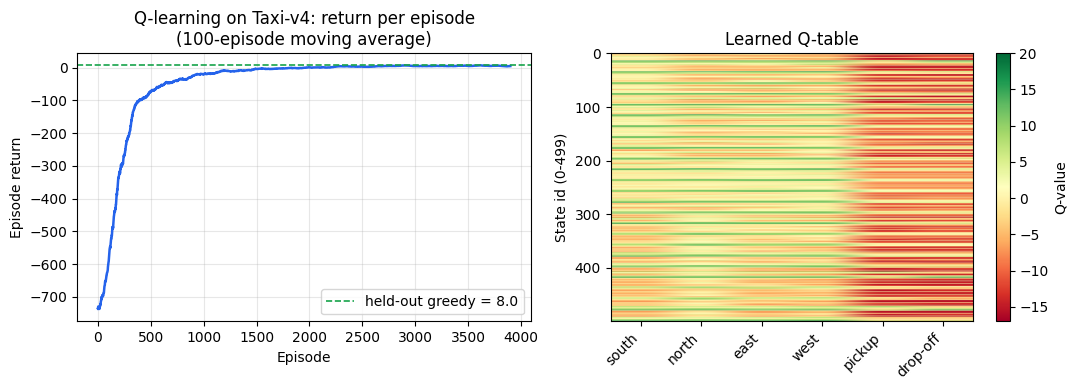

In [1]:
# WHAT: tabular Q-learning on Gymnasium's Taxi benchmark — the full loop, end to end.
# WHY: Taxi is a published, reproducible dispatch task (500 states, 6 actions). Using a
#      standard benchmark instead of a made-up world means the numbers printed below can be
#      compared against any textbook, tutorial or paper that reports on the same environment.

import time

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np


def make_taxi():
    """Build the Taxi environment, tolerating the Gymnasium v3 -> v4 rename."""
    # Newer Gymnasium registers "Taxi-v4"; older releases only know "Taxi-v3".
    for env_id in ("Taxi-v4", "Taxi-v3"):
        try:
            return gym.make(env_id), env_id
        except Exception:
            continue
    raise RuntimeError("Taxi is not registered in this Gymnasium installation.")


env, ENV_ID = make_taxi()
N_STATES = env.observation_space.n          # 500 packed (taxi, passenger, destination) states
N_ACTIONS = env.action_space.n              # 6 moves
ACTION_NAMES = ["south", "north", "east", "west", "pickup", "drop-off"]

print("=" * 62)
print(f"Environment : {ENV_ID}  (Gymnasium {gym.__version__})")
print(f"States      : {N_STATES}     Actions: {N_ACTIONS} -> {', '.join(ACTION_NAMES)}")
print("Rewards     : -1 per step, +20 correct drop-off, -10 illegal pickup/drop-off")
print("=" * 62)

# ── Hyper-parameters ────────────────────────────────────────────────────────────
ALPHA = 0.5        # learning rate: how far each experience moves the estimate
GAMMA = 0.95       # discount: how much future reward still counts today
EPS_START, EPS_MIN, EPS_DECAY = 1.0, 0.05, 0.999   # exploration schedule
EPISODES = 4000
MAX_STEPS = 200

# One seeded generator drives exploration, so this whole notebook reruns identically.
rng = np.random.default_rng(42)

Q = np.zeros((N_STATES, N_ACTIONS))   # the table we are learning: one value per (state, action)
epsilon = EPS_START
returns_history = []

# ── Training loop ───────────────────────────────────────────────────────────────
start_time = time.perf_counter()
for episode in range(EPISODES):
    # Seeding reset per episode makes the sequence of start states reproducible.
    state, _ = env.reset(seed=episode)
    episode_return = 0.0
    for _ in range(MAX_STEPS):
        # ε-greedy behaviour: explore with probability epsilon, otherwise act greedily.
        if rng.random() < epsilon:
            action = int(rng.integers(N_ACTIONS))
        else:
            action = int(Q[state].argmax())
        next_state, reward, terminated, truncated, _ = env.step(action)
        # THE Q-LEARNING UPDATE. Note `max` over the NEXT state: the target uses the best
        # action available there, not the action the agent will actually take. That single
        # `max` is what makes Q-learning off-policy.
        Q[state, action] += ALPHA * (reward + GAMMA * Q[next_state].max() - Q[state, action])
        state = next_state
        episode_return += reward
        if terminated or truncated:
            break
    returns_history.append(episode_return)
    epsilon = max(epsilon * EPS_DECAY, EPS_MIN)
train_seconds = time.perf_counter() - start_time

returns_history = np.array(returns_history)
first_100 = returns_history[:100].mean()
last_100 = returns_history[-100:].mean()
print(f"\nTrained {EPISODES} episodes in {train_seconds:.1f}s (final epsilon {epsilon:.3f}).")
print(f"Mean return over the FIRST 100 episodes : {first_100:8.1f}")
print(f"Mean return over the LAST  100 episodes : {last_100:8.1f}")


# ── Held-out evaluation ─────────────────────────────────────────────────────────
def evaluate(choose_action, n_episodes=200, seed_offset=100_000):
    """Run a fixed policy on episodes never used in training; return (mean return, mean steps, solved %)."""
    total_returns, total_steps, solved = [], [], 0
    for k in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + k)
        episode_return, steps, delivered = 0.0, 0, False
        for _ in range(MAX_STEPS):
            obs, reward, terminated, truncated, _ = env.step(choose_action(obs))
            episode_return += reward
            steps += 1
            if terminated:
                delivered = True          # terminated == passenger delivered correctly
            if terminated or truncated:
                break
        total_returns.append(episode_return)
        total_steps.append(steps)
        solved += int(delivered)
    return float(np.mean(total_returns)), float(np.mean(total_steps)), solved / n_episodes


learned = evaluate(lambda s: int(Q[s].argmax()))
random_baseline = evaluate(lambda s: int(rng.integers(N_ACTIONS)))

print("\nHeld-out evaluation on 200 episodes the agent never trained on:")
print(f"  {'policy':<22}{'mean return':>13}{'mean steps':>12}{'delivered':>12}")
print(f"  {'learned (greedy Q)':<22}{learned[0]:>13.2f}{learned[1]:>12.1f}{learned[2]*100:>11.1f}%")
print(f"  {'random actions':<22}{random_baseline[0]:>13.2f}{random_baseline[1]:>12.1f}{random_baseline[2]*100:>11.1f}%")

# Decode a few REAL start states so the policy readout is concrete, not abstract.
print("\nWhat the greedy policy does in five real start states:")
for k in range(5):
    obs, _ = env.reset(seed=900_000 + k)
    taxi_row, taxi_col, passenger, destination = env.unwrapped.decode(obs)
    where = "in the taxi" if passenger == 4 else f"waiting at stop {passenger}"
    print(f"  state {obs:3d}: taxi at ({taxi_row},{taxi_col}), passenger {where}, "
          f"destination stop {destination}  ->  {ACTION_NAMES[int(Q[obs].argmax())]}")

print("\nReading note: the table above is the greedy policy READ OFF the learned Q-table.")
print("It is an estimate from experience, not a proof of optimality — states the agent")
print("rarely visited still hold noisy values.")

# ── Figures ─────────────────────────────────────────────────────────────────────
moving_average = np.convolve(returns_history, np.ones(100) / 100, mode="valid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(moving_average, color="#2563eb", linewidth=1.8)
axes[0].axhline(learned[0], color="#16a34a", linestyle="--", linewidth=1.2,
                label=f"held-out greedy = {learned[0]:.1f}")
axes[0].set_title(f"Q-learning on {ENV_ID}: return per episode\n(100-episode moving average)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Episode return")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

heat = axes[1].imshow(Q, aspect="auto", cmap="RdYlGn")
fig.colorbar(heat, ax=axes[1], label="Q-value")
axes[1].set_xticks(range(N_ACTIONS))
axes[1].set_xticklabels(ACTION_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("State id (0-499)")
axes[1].set_title("Learned Q-table")
plt.tight_layout()
plt.show()


## Summary

This notebook should leave you with four core ideas:

- Q-learning updates **action values**, not the policy directly.
- It is **off-policy** because it updates toward the greedy next action (the `max` in the update).
- `alpha` controls how fast estimates change.
- `epsilon` controls how much the agent still explores.

**What the run above actually showed.** On the Gymnasium **Taxi** benchmark the agent started
from a Q-table of zeros and learned only from interaction — it was never given the transition
table or the reward table. The held-out comparison in the output is the evidence: the learned
greedy policy against a random policy, on 200 episodes the agent never trained on. Read those
two rows from your own run, not from memory.

Important reading note: the displayed "optimal policy" is the **greedy policy induced by the
current Q-table at the end of training**. It is a useful estimate, not a formal proof of global
optimality — and because Taxi has 500 states, some of them were visited only a handful of times.

### Next step

After this notebook, compare it with SARSA and Monte Carlo methods so you can see
how different model-free methods learn from experience in different ways.

In [2]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6, Temporal-Difference Learning.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
"""))

## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6, Temporal-Difference Learning.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


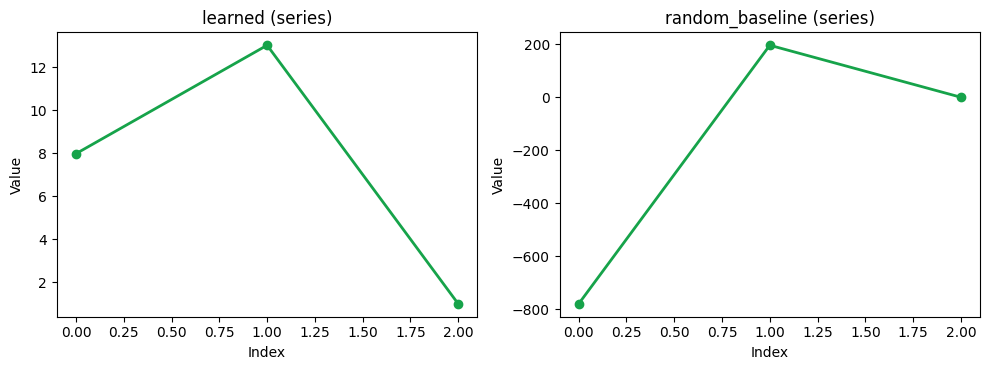

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Q-learning updates action values toward a better estimate of future return without needing a full environment model.

**If students remember one idea:** The update rule is simple, but its meaning is powerful: revise what you believe about an action after each new experience.

**Quick check before moving on:**
- Can you explain each term in the Q-learning update rule?
- Can you describe why Q-learning is called an off-policy method?
- On Taxi, why is a single correct move worth so little on its own?

**Bridge to the next step:** Next, you will compare this with SARSA to see how learning changes when the next chosen action matters directly.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.

## Motion recap (optional)

**At a glance:** The next cell uses a **random** policy on FrozenLake. **Not reaching the goal tile `G` is normal and intended**—the point is to see the **API loop** (state → action → reward → next state) in motion, not to prove a solved policy. If the episode ends in a hole or times out, the demo is still doing its job.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


Teaching note: random FrozenLake rollouts may not reach G—this is expected. Read state→action→reward over time, not 'did it win?'.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=12 | term=True | trunc=False


objc[9732]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1105b0138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110aac9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9732]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1105b0188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110aaca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9732]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1105afc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110aaca68). This

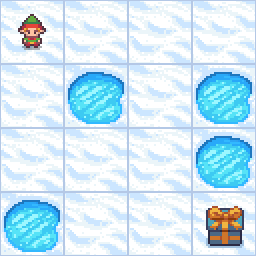

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

print(
    "Teaching note: random FrozenLake rollouts may not reach G—this is expected. "
    "Read state→action→reward over time, not 'did it win?'."
)

# Install the visual-demo dependencies quietly (safe to rerun; already-installed packages are skipped).
%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
